# AI Use Declaration

We declare that we used the following AI tools for the following purposes, but no AI was used in directly
solving the problem by entering the problem statement or any part thereof into any AI tool.

ChatGPT for generating the hyperparameters to be tuned by the Random Search CV.
Github Copilot for debugging syntax errors.

In [1]:
import pandas as pd
import warnings
import numpy as np
from time import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, RepeatedStratifiedKFold
from scipy.stats import randint, loguniform, uniform
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.ensemble import GradientBoostingRegressor
# import xgboost as xgb
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

warnings.filterwarnings("ignore")

wine_data = pd.read_csv('winequality-red.csv', sep=';')

print("--- Initial Data Overview ---")
print("\nFirst 5 Rows:")
print(wine_data.head())
print(f"\nDataset Shape: {wine_data.shape}")
print("\nDataset Info:")
wine_data.info()
print("\nDescriptive Statistics:")
print(wine_data.describe())

X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

print("\n--- Data Preparation ---")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Unique target values: {sorted(y.unique())}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5, stratify=y
)

print("\n--- Data Splitting ---")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

--- Initial Data Overview ---

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5

Starting RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END regress__activation=tanh, regress__alpha=0.0007396344148036071, regress__hidden_layer_sizes=(50, 25), regress__solver=sgd;, score=0.462 total time=   0.5s
[CV 2/5] END regress__activation=tanh, regress__alpha=0.0007396344148036071, regress__hidden_layer_sizes=(50, 25), regress__solver=sgd;, score=0.308 total time=   0.5s
[CV 3/5] END regress__activation=tanh, regress__alpha=0.0007396344148036071, regress__hidden_layer_sizes=(50, 25), regress__solver=sgd;, score=0.325 total time=   0.5s
[CV 4/5] END regress__activation=tanh, regress__alpha=0.0007396344148036071, regress__hidden_layer_sizes=(50, 25), regress__solver=sgd;, score=0.338 total time=   0.4s
[CV 5/5] END regress__activation=tanh, regress__alpha=0.0007396344148036071, regress__hidden_layer_sizes=(50, 25), regress__solver=sgd;, score=0.343 total time=   0.5s
[CV 1/5] END regress__activation=relu, regress__alpha=0.00068142578

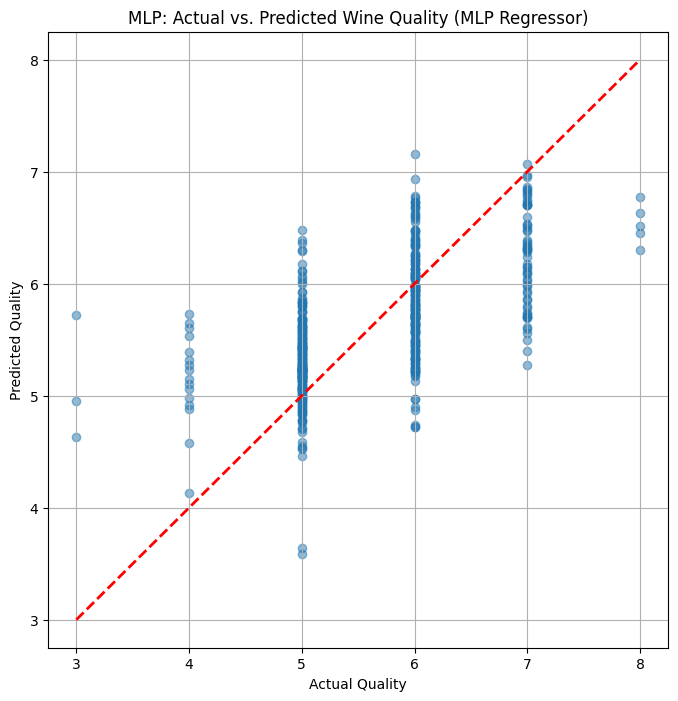

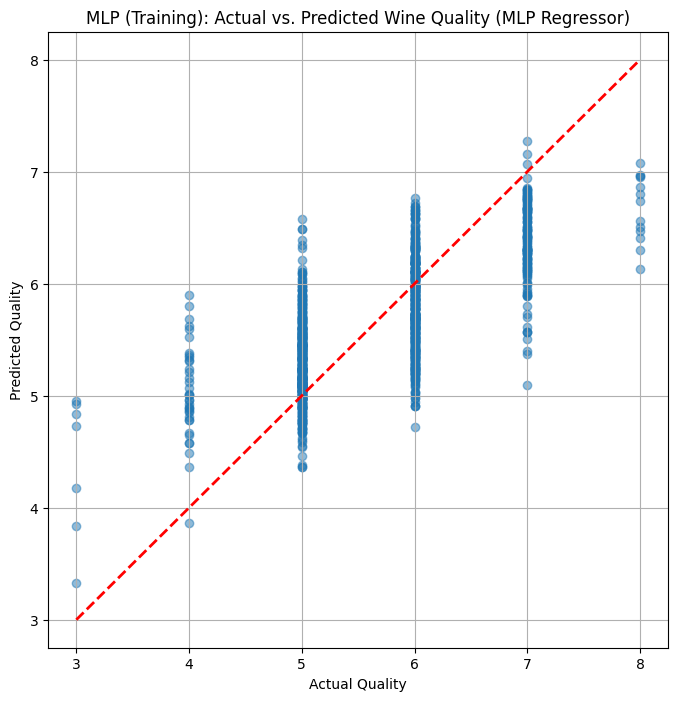

Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.25      0.06      0.10        16
           5       0.70      0.72      0.71       204
           6       0.56      0.66      0.60       192
           7       0.49      0.32      0.38        60
           8       0.00      0.00      0.00         5

    accuracy                           0.61       480
   macro avg       0.33      0.29      0.30       480
weighted avg       0.59      0.61      0.59       480



In [2]:
pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("regress", MLPRegressor(max_iter=5000, random_state=5))] # Add random_state for reproducibility
)

model_params = {
    'regress__alpha': loguniform(1e-4, 10),
    'regress__solver': ['sgd', 'adam'],
    'regress__hidden_layer_sizes': [
        (100,),              
        (50, 25),           
    ],
    'regress__activation': ['tanh', 'relu'] 
}

n_iter = 20
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=model_params,
    n_iter=n_iter,
    verbose=3
)

print("Starting RandomizedSearchCV...")
start = time()
random_search.fit(X_train, y_train)
print(f"RandomizedSearchCV took {time() - start:.2f} seconds for {n_iter} candidate settings.")
print("\nBest parameters found:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2  = r2_score(y_test, y_pred_test)
test_mad = mean_absolute_error(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2  = r2_score(y_train, y_pred_train)
train_mad = mean_absolute_error(y_train, y_pred_train)

print("\n--- Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

print("\n--- Performance on Training Data ---")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R-squared (R2): {train_r2:.4f}")
print(f"Training Mean Absolute Deviation (MAD): {train_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2) # The "perfect prediction" line
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("MLP: Actual vs. Predicted Wine Quality (MLP Regressor)")
plt.grid()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred_train, alpha=0.5)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'r--', lw=2) # The "perfect prediction" line
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("MLP (Training): Actual vs. Predicted Wine Quality (MLP Regressor)")
plt.grid()
plt.show()

y_pred_test_class = np.round(y_pred_test).astype(int)
y_pred_test_class = np.clip(y_pred_test_class, y.min(), y.max())
print('Test Classification Report')
print(classification_report(y_test, y_pred_test_class))
plt.show()

Starting SVR hyperparameter tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END regress__C=0.7726319876517099, regress__degree=3, regress__gamma=0.0004170205589203407, regress__kernel=rbf;, score=0.334 total time=   0.0s
[CV 2/5] END regress__C=0.7726319876517099, regress__degree=3, regress__gamma=0.0004170205589203407, regress__kernel=rbf;, score=0.283 total time=   0.0s
[CV 3/5] END regress__C=0.7726319876517099, regress__degree=3, regress__gamma=0.0004170205589203407, regress__kernel=rbf;, score=0.257 total time=   0.0s
[CV 4/5] END regress__C=0.7726319876517099, regress__degree=3, regress__gamma=0.0004170205589203407, regress__kernel=rbf;, score=0.299 total time=   0.0s
[CV 5/5] END regress__C=0.7726319876517099, regress__degree=3, regress__gamma=0.0004170205589203407, regress__kernel=rbf;, score=0.292 total time=   0.0s
[CV 1/5] END regress__C=827.5228539305427, regress__degree=2, regress__gamma=0.006842764422737332, regress__kernel=rbf;, score=0.4

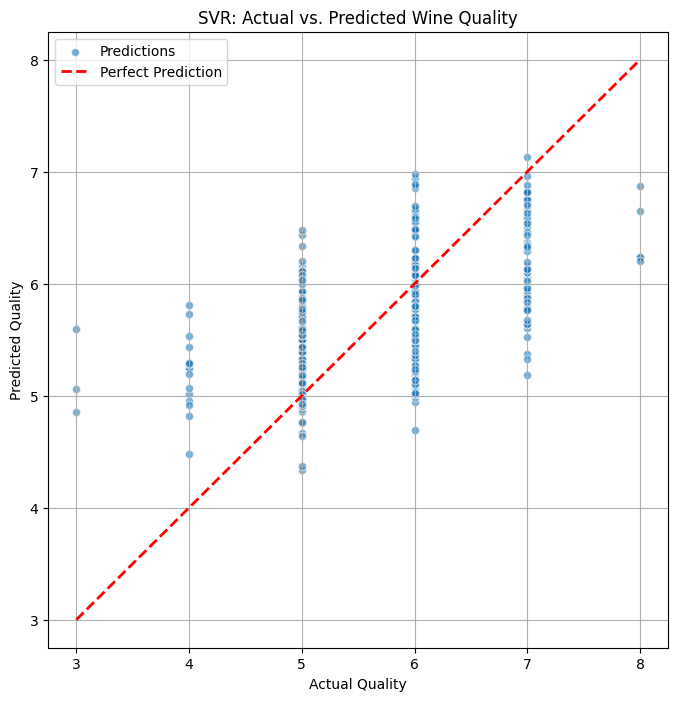

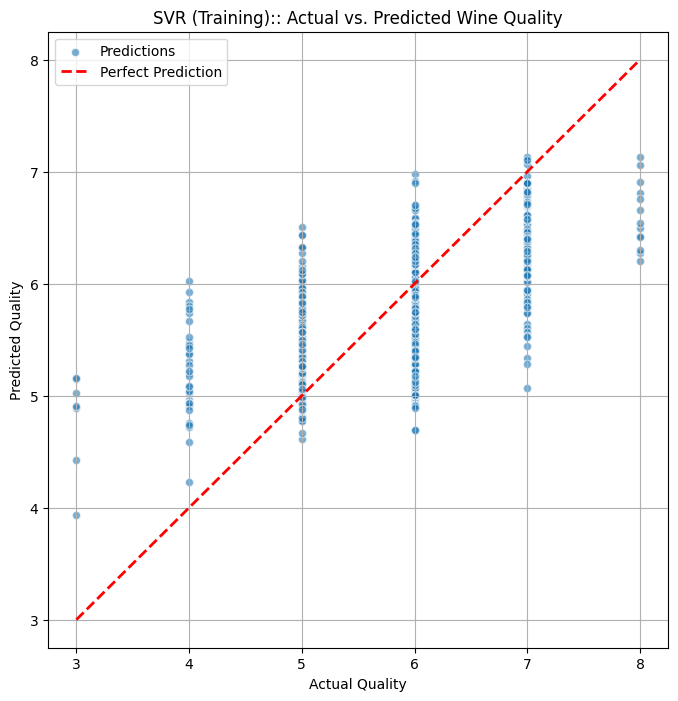

Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.33      0.06      0.11        16
           5       0.66      0.74      0.70       204
           6       0.55      0.59      0.57       192
           7       0.50      0.35      0.41        60
           8       0.00      0.00      0.00         5

    accuracy                           0.60       480
   macro avg       0.34      0.29      0.30       480
weighted avg       0.57      0.60      0.58       480



In [3]:
pipeline = Pipeline([
    ('preprocess', StandardScaler()),
    ('regress', SVR())
])

model_params = {
    'regress__C': loguniform(1e-1, 1e3),
    'regress__gamma': loguniform(1e-4, 1e-1),
    'regress__kernel': ['rbf', 'poly', 'sigmoid'],
    'regress__degree': [2, 3, 4]
}

n_iter = 20
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=model_params,
    n_iter=n_iter,
    verbose=3,
    random_state=5
)

print("Starting SVR hyperparameter tuning...")
random_search.fit(X_train, y_train)

print("\nBest SVR parameters found:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2  = r2_score(y_test, y_pred_test)
test_mad = mean_absolute_error(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2  = r2_score(y_train, y_pred_train)
train_mad = mean_absolute_error(y_train, y_pred_train)

print("\n--- Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

print("\n--- Performance on Training Data ---")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R-squared (R2): {train_r2:.4f}")
print(f"Training Mean Absolute Deviation (MAD): {train_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='w', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("SVR: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred_train, alpha=0.6, edgecolors='w', label='Predictions')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("SVR (Training):: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

y_pred_test_class = np.round(y_pred_test).astype(int)
y_pred_test_class = np.clip(y_pred_test_class, y.min(), y.max())
print('Test Classification Report')
print(classification_report(y_test, y_pred_test_class))
plt.show()

In [4]:

# dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
# dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

# params = {"objective": "reg:squarederror"}
# n = 100

# model = xgb.train(
#    params=params,
#    dtrain=dtrain_reg,
#    num_boost_round=n
# )

# y_pred_train = model.predict(dtrain_reg)
# y_pred_test = model.predict(dtest_reg)


# train_mse = mean_squared_error(y_train, y_pred_train)
# test_mse = mean_squared_error(y_test, y_pred_test)
# print(f"Training MSE: {train_mse}")
# print(f"Testing MSE: {test_mse}")

# train_r2  = r2_score(y_train, y_pred_train)
# test_r2   = r2_score(y_test, y_pred_test)
# train_mad = mean_absolute_error(y_train, y_pred_train)
# test_mad  = mean_absolute_error(y_test, y_pred_test)

# print(f"Training R2: {train_r2}, Training MAD: {train_mad}")
# print(f"Testing R2: {test_r2}, Testing MAD: {test_mad}")

# plt.figure(figsize=(8, 8))
# plt.scatter(y_test, y_pred_test, alpha=0.6, label='Predictions')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
# plt.xlabel("Actual Quality")
# plt.ylabel("Predicted Quality")
# plt.title("XGBoost: Actual vs. Predicted Wine Quality")
# plt.legend()
# plt.grid(True)
# plt.show()

# plt.figure(figsize=(8, 8))
# plt.scatter(y_train, y_pred_train, alpha=0.6, edgecolors='w', label='Predictions')
# plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
# plt.xlabel("Actual Quality")
# plt.ylabel("Predicted Quality")
# plt.title("XGBoost (Training): Actual vs. Predicted Wine Quality")
# plt.legend()
# plt.grid(True)
# plt.show()

Starting hyperparameter tuning for Random Forest Regressor...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END regress__max_depth=7, regress__n_estimators=120;, score=0.511 total time=   0.2s
[CV 2/5] END regress__max_depth=7, regress__n_estimators=120;, score=0.371 total time=   0.2s
[CV 3/5] END regress__max_depth=7, regress__n_estimators=120;, score=0.387 total time=   0.2s
[CV 4/5] END regress__max_depth=7, regress__n_estimators=120;, score=0.417 total time=   0.2s
[CV 5/5] END regress__max_depth=7, regress__n_estimators=120;, score=0.454 total time=   0.3s
[CV 1/5] END regress__max_depth=2, regress__n_estimators=366;, score=0.393 total time=   0.3s
[CV 2/5] END regress__max_depth=2, regress__n_estimators=366;, score=0.224 total time=   0.4s
[CV 3/5] END regress__max_depth=2, regress__n_estimators=366;, score=0.269 total time=   0.4s
[CV 4/5] END regress__max_depth=2, regress__n_estimators=366;, score=0.291 total time=   0.4s
[CV 5/5] END regress__max_dept

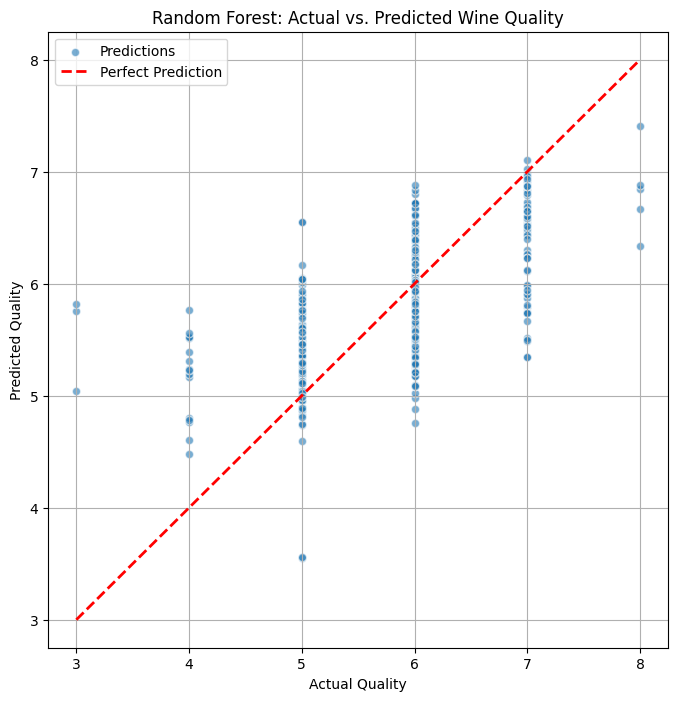

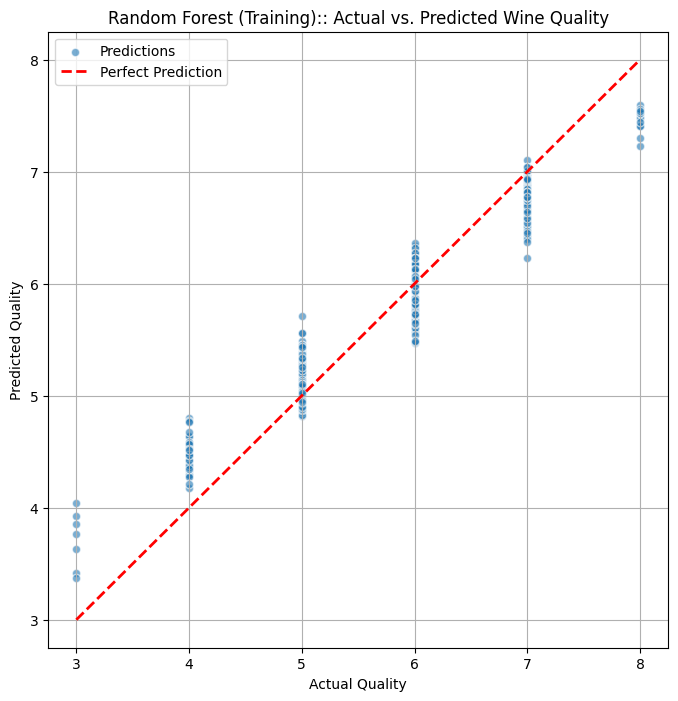

Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.33      0.06      0.11        16
           5       0.74      0.79      0.76       204
           6       0.65      0.69      0.67       192
           7       0.58      0.52      0.55        60
           8       0.00      0.00      0.00         5

    accuracy                           0.68       480
   macro avg       0.38      0.34      0.35       480
weighted avg       0.66      0.68      0.66       480



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

pipeline = Pipeline([
    ('preprocess', StandardScaler()),
    ('regress', RandomForestRegressor(random_state=5))
])

model_params = {
    'regress__n_estimators': randint(50, 500),
    'regress__max_depth': randint(1, 20)
}

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=3)

print("Starting hyperparameter tuning for Random Forest Regressor...")
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
print("\nBest hyperparameters found:")
print(random_search.best_params_)

y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
test_mad = mean_absolute_error(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)
train_mad = mean_absolute_error(y_train, y_pred_train)

print("\n--- Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

print("\n--- Performance on Training Data ---")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R-squared (R2): {train_r2:.4f}")
print(f"Training Mean Absolute Deviation (MAD): {train_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='w', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Random Forest: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred_train, alpha=0.6, edgecolors='w', label='Predictions')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Random Forest (Training):: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

y_pred_test_class = np.round(y_pred_test).astype(int)
y_pred_test_class = np.clip(y_pred_test_class, y.min(), y.max())
print('Test Classification Report')
print(classification_report(y_test, y_pred_test_class))
plt.show()

Starting Gradient Boosting hyperparameter tuning with a pipeline...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END regress__max_depth=16, regress__n_estimators=435;, score=0.221 total time=   1.0s
[CV 2/5] END regress__max_depth=16, regress__n_estimators=435;, score=0.189 total time=   0.9s
[CV 3/5] END regress__max_depth=16, regress__n_estimators=435;, score=0.070 total time=   0.8s
[CV 4/5] END regress__max_depth=16, regress__n_estimators=435;, score=0.043 total time=   0.8s
[CV 5/5] END regress__max_depth=16, regress__n_estimators=435;, score=0.263 total time=   0.9s
[CV 1/5] END regress__max_depth=15, regress__n_estimators=136;, score=0.243 total time=   0.6s
[CV 2/5] END regress__max_depth=15, regress__n_estimators=136;, score=0.171 total time=   0.6s
[CV 3/5] END regress__max_depth=15, regress__n_estimators=136;, score=0.091 total time=   0.7s
[CV 4/5] END regress__max_depth=15, regress__n_estimators=136;, score=0.194 total time=   0.7s
[CV 5/5] END re

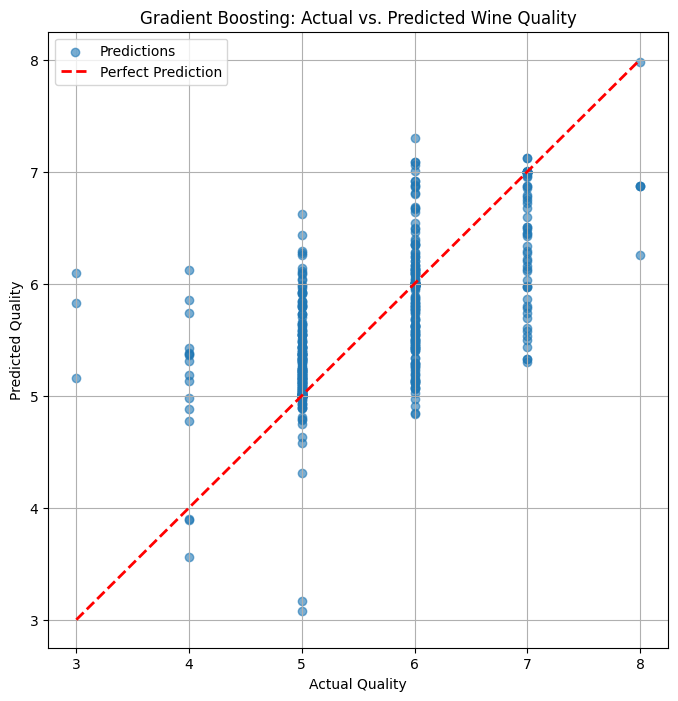

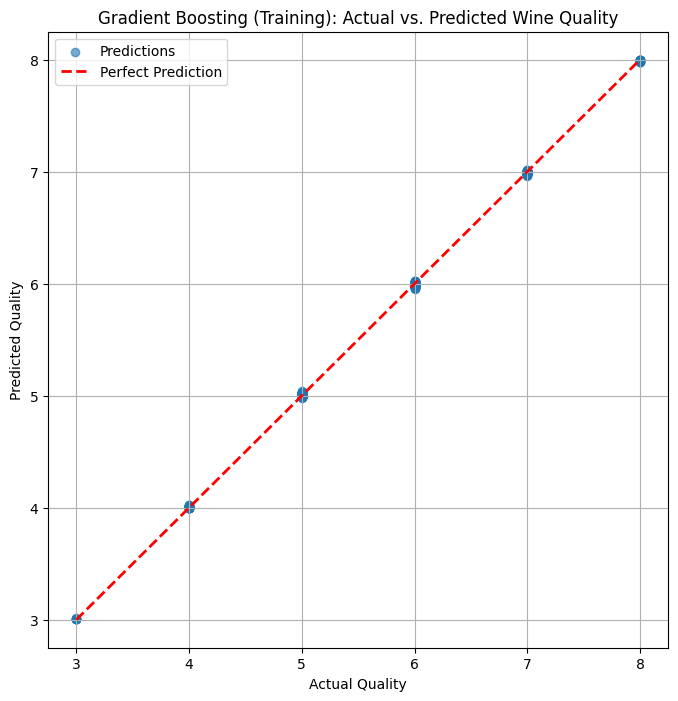

Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.75      0.19      0.30        16
           5       0.71      0.75      0.73       204
           6       0.62      0.67      0.64       192
           7       0.60      0.52      0.55        60
           8       1.00      0.20      0.33         5

    accuracy                           0.66       480
   macro avg       0.61      0.39      0.43       480
weighted avg       0.66      0.66      0.65       480



In [6]:
pipeline = Pipeline([
    ('preprocessing', StandardScaler()),
    ('regress', GradientBoostingRegressor(random_state=5))
])

param_grid = {
    'regress__n_estimators': randint(100, 500),
    'regress__max_depth': randint(3, 10),
    'regress__learning_rate': uniform(0.01, 0.2),
    'regress__subsample': uniform(0.7, 0.3),
    'regress__min_samples_leaf': randint(1, 5)
}

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=3)

print("Starting Gradient Boosting hyperparameter tuning with a pipeline...")
random_search.fit(X_train, y_train)

print("\nBest Gradient Boosting parameters found:")
print(random_search.best_params_)

best_model = random_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
test_mad = mean_absolute_error(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)
train_mad = mean_absolute_error(y_train, y_pred_train)

print("\n--- Gradient Boosting Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

print("\n--- Performance on Training Data ---")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R-squared (R2): {train_r2:.4f}")
print(f"Training Mean Absolute Deviation (MAD): {train_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Gradient Boosting: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred_train, alpha=0.6, label='Predictions')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Gradient Boosting (Training): Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

y_pred_test_class = np.round(y_pred_test).astype(int)
y_pred_test_class = np.clip(y_pred_test_class, y.min(), y.max())
print('Test Classification Report')
print(classification_report(y_test, y_pred_test_class))
plt.show()

## SVR
**Regression metrics (test):**  
- MSE: `0.4151`  
- R²: `0.3598`  
- MAD: `0.4871`

**Classification report**

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| 3 | 0.00 | 0.00 | 0.00 | 3 |
| 4 | 0.33 | 0.06 | 0.11 | 16 |
| 5 | 0.66 | 0.74 | 0.70 | 204 |
| 6 | 0.55 | 0.59 | 0.57 | 192 |
| 7 | 0.50 | 0.35 | 0.41 | 60 |
| 8 | 0.00 | 0.00 | 0.00 | 5 |
| **accuracy** |  |  | **0.60** | **480** |
| **macro avg** | **0.34** | **0.29** | **0.30** | **480** |
| **weighted avg** | **0.57** | **0.60** | **0.58** | **480** |

---

## MLPR
**Regression metrics (test):**  
- MSE: `0.4125`  
- R²: `0.3637`  
- MAD: `0.5006`

**Classification report**

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| 3 | 0.00 | 0.00 | 0.00 | 3 |
| 4 | 0.25 | 0.06 | 0.10 | 16 |
| 5 | 0.67 | 0.69 | 0.68 | 204 |
| 6 | 0.53 | 0.62 | 0.57 | 192 |
| 7 | 0.49 | 0.32 | 0.38 | 60 |
| 8 | 0.00 | 0.00 | 0.00 | 5 |
| **accuracy** |  |  | **0.59** | **480** |
| **macro avg** | **0.32** | **0.28** | **0.29** | **480** |
| **weighted avg** | **0.57** | **0.59** | **0.57** | **480** |

---

## GBR
**Regression metrics (test):**  
- MSE: `0.3993`  
- R²: `0.3842`  
- MAD: `0.4218`

**Classification report**

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| 3 | 0.00 | 0.00 | 0.00 | 3 |
| 4 | 0.80 | 0.25 | 0.38 | 16 |
| 5 | 0.71 | 0.75 | 0.73 | 204 |
| 6 | 0.63 | 0.67 | 0.65 | 192 |
| 7 | 0.65 | 0.57 | 0.61 | 60 |
| 8 | 0.33 | 0.20 | 0.25 | 5 |
| **accuracy** |  |  | **0.67** | **480** |
| **macro avg** | **0.52** | **0.41** | **0.44** | **480** |
| **weighted avg** | **0.67** | **0.67** | **0.66** | **480** |

---

## RFR
**Regression metrics (test):**  
- MSE: `0.3540`  
- R²: `0.4539`  
- MAD: `0.4336`

**Classification report**

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| 3 | 0.00 | 0.00 | 0.00 | 3 |
| 4 | 0.33 | 0.06 | 0.11 | 16 |
| 5 | 0.73 | 0.78 | 0.76 | 204 |
| 6 | 0.64 | 0.69 | 0.66 | 192 |
| 7 | 0.58 | 0.52 | 0.55 | 60 |
| 8 | 0.00 | 0.00 | 0.00 | 5 |
| **accuracy** |  |  | **0.68** | **480** |
| **macro avg** | **0.38** | **0.34** | **0.35** | **480** |
| **weighted avg** | **0.65** | **0.68** | **0.66** | **480** |


We now treat this as a regression problem. Using the same Bcross-validation with 20 iterations per 5-fold CVs to find the optimal hyperparameters, we now observe that MLP regressor has the lowest accuracy of 59%, before being followed by SVR at 60%. Both gradient boosting and random forest regressors still maintain the top spot at 67% and 68% accuracies, respectively. It is interesting to observe that tree-based algorithms consistently outperform SVMs and MLPs in both classification and regression cases. In the regression case, only the RF and GB regression were able to beat the 62.4% accuracy of the paper. Now comparing the mean average deviation, MLP regressor is at 0.5, followed by SVR at 0.49. RF regressor is next at 0.434, with GB regressor at 0.422. Again only the RF and GB regressors outperform the MAD in the paper of 0.46, showing similar trends with the accuracy and other metrics. The continuous nature of classification preserves ordering and does not penalize the smaller deviations as much as classification.

While using a classifier may make it simpler to assign quality labels to wines, it might be more difficult to determine the closeness of the sample to a class due to the inherent "rounding". This is useful if we want labels right away. However, it would be more beneficial to utilize regression as to adjust the tolerances of the model to errors and also keeps the deviation metric of a sample from a class. This can then be binned to labels afterwards as what was done above.